-----

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df_companies = pd.read_csv('/datasets/project_sql_result_01.csv')
df_neighborhoods = pd.read_csv('/datasets/project_sql_result_04.csv')

In [3]:
print(df_companies.head())
print()
print(df_companies.info())
print()
print(df_neighborhoods.head())
print()
print(df_neighborhoods.info())

                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                Medallion Leasing         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None

  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count

In [4]:
top_10_neighborhoods = df_neighborhoods.sort_values(by='average_trips', ascending=False).head(10)
display(top_10_neighborhoods)

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


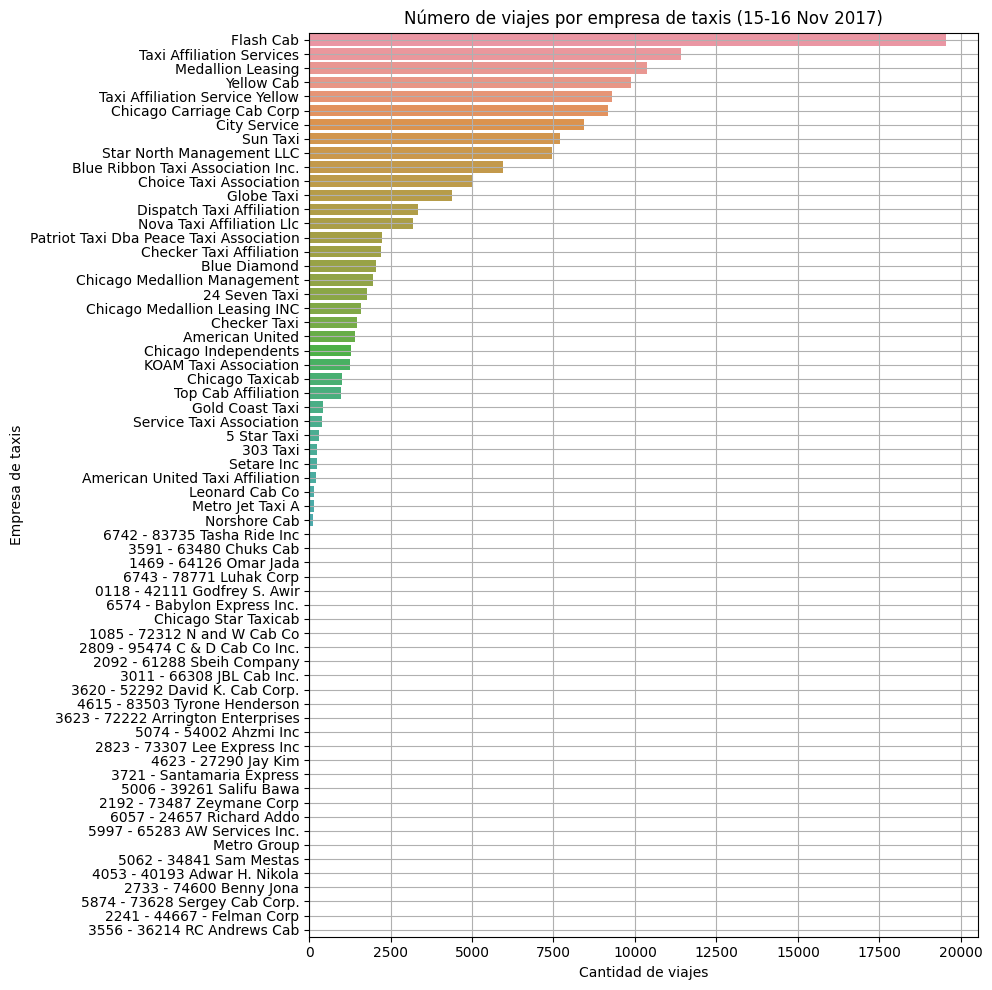

In [5]:
plt.figure(figsize=(10,10))
sns.barplot(x='trips_amount', y='company_name', data=df_companies.sort_values(by='trips_amount', ascending=False))
plt.grid()
plt.title('Número de viajes por empresa de taxis (15-16 Nov 2017)')
plt.xlabel('Cantidad de viajes')
plt.ylabel('Empresa de taxis')
plt.tight_layout()
plt.show()

Podemos observar que en las fechas 15 y 16 de Noviembre la compañia que mas viajes tuvo fue "Flash Cab" con casi 20 mil  viajes.

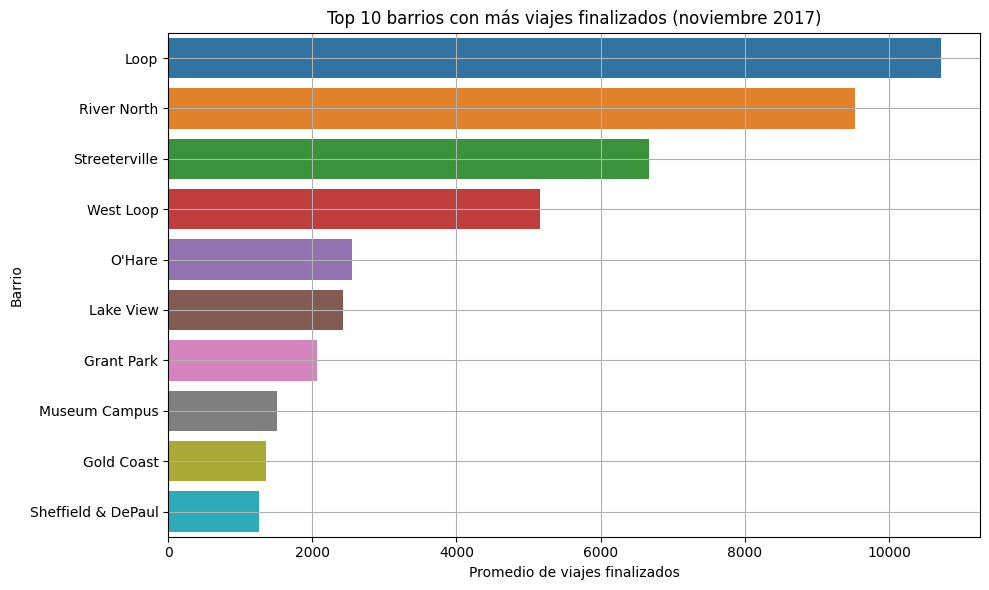

In [6]:
plt.figure(figsize=(10,6))
sns.barplot(x='average_trips', y='dropoff_location_name', data=top_10_neighborhoods)
plt.title('Top 10 barrios con más viajes finalizados (noviembre 2017)')
plt.grid()
plt.xlabel('Promedio de viajes finalizados')
plt.ylabel('Barrio')
plt.tight_layout()
plt.show()

Podemos observar que los barrios en los que mas viajes fueron finalizados son "Loop" y "River North" ambos con mas de 9 mil viajes.

In [7]:


from scipy import stats

# Cargar datos
df_weather_trips = pd.read_csv('/datasets/project_sql_result_07.csv')

# Convertir fechas
df_weather_trips['start_ts'] = pd.to_datetime(df_weather_trips['start_ts'])

# Crear columna con el nombre del día de la semana
df_weather_trips['weekday'] = df_weather_trips['start_ts'].dt.day_name()

# Filtrar sábados
saturdays = df_weather_trips[df_weather_trips['weekday'] == 'Saturday']

# Filtrar por condiciones meteorológicas
rain_conditions = saturdays[saturdays['weather_conditions'] == 'Bad']      # Días con mal clim
no_rain_conditions = saturdays[saturdays['weather_conditions'] == 'Good']  # Días con buen clima

# Eliminar NaN en duración
rain_durations = rain_conditions['duration_seconds'].dropna()
no_rain_durations = no_rain_conditions['duration_seconds'].dropna()

# Verificar tamaños
print(f"Lluvia: {len(rain_durations)}, Sin lluvia: {len(no_rain_durations)}")

# Comprobar si hay suficientes datos
if len(rain_durations) > 1 and len(no_rain_durations) > 1:
    alpha = 0.05
    t_stat, p_value = stats.ttest_ind(rain_durations, no_rain_durations, equal_var=False)
    print(f"Estadístico t: {t_stat:.2f}")
    print(f"Valor p: {p_value:.4f}")

    if p_value < alpha:
        print("Rechazamos la hipótesis nula: hay diferencia significativa en la duración de los viajes los sábados con mal clima.")
    else:
        print("No se puede rechazar la hipótesis nula: no hay evidencia suficiente para afirmar que el clima afecta la duración.")
else:
    print("No hay suficientes datos en uno o ambos grupos para realizar la prueba t.")
print()
print(df_weather_trips['weather_conditions'].unique())

Lluvia: 180, Sin lluvia: 888
Estadístico t: 7.19
Valor p: 0.0000
Rechazamos la hipótesis nula: hay diferencia significativa en la duración de los viajes los sábados con mal clima.

['Good' 'Bad']
